# Decoding Motor Imagery: A Hybrid WPD-CSP-MLP Approach

**Dataset:** BCI Competition IV-2a (Subject A01T) | **Classes:** Left Hand, Right Hand, Feet, Tongue

This notebook walks through an end-to-end pipeline for classifying motor imagery from raw EEG signals. Processing EEG data is inherently challenging due to noise and low spatial resolution, so we implement a hybrid feature engineering approach before feeding the data into a neural network.

### The Pipeline at a Glance
Instead of relying on a single method, we combine temporal, frequency, and spatial analyses:

*   **1. Preprocessing (MNE-Python):** Cleaning the raw signals using filtering and ICA to isolate artifact-free EEG epochs.
*   **2. Feature Extraction (WPD & CSP):** We first apply Wavelet Packet Decomposition (WPD) to extract time-frequency sub-bands. Then, we use Common Spatial Patterns (CSP) as a filter bank on these sub-bands to extract highly discriminative spatial features.
*   **3. Classification (PyTorch):** Training a Multi-Layer Perceptron (MLP) on the hybrid feature vector to classify the 4 motor tasks.
*   **4. Evaluation:** Assessing model performance through confusion matrices, learning curves, CSP topomaps, and WPD energy distributions.


## 0. Setup


In [3]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mne
import pywt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

from mne.decoding import CSP

# ---- Reproducibility ----
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

mne.set_log_level('WARNING')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)


Using device: cpu


## 1. Loading Data and Preprocessing

### 1.1 Loading the raw recording

We load the raw GDF file with MNE. The file contains **25 channels**: 22 EEG +
3 EOG, sampled at **250 Hz**, already hardware-filtered between 0.5-100 Hz.

In [4]:
raw = mne.io.read_raw_gdf('data/raw/A01T.gdf', preload=True)
print(raw)
raw.info


<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-17 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-17>
>

### 1.2 Channel naming and montage



In [5]:
# Standard 10-20 mapping for the BCI Competition IV-2a montage (Brunner et al., 2008)
channel_mapping = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4',
    'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2',
    'EEG-C4': 'C4', 'EEG-8': 'C6',
    'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
    'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz',
}
raw.rename_channels(channel_mapping)
raw.set_channel_types({'EOG-left': 'eog', 'EOG-central': 'eog', 'EOG-right': 'eog'})

montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')

print(f"EEG channels: {len(mne.pick_types(raw.info, eeg=True))}")
print(f"EOG channels: {len(mne.pick_types(raw.info, eog=True))}")
fig = raw.plot_sensors(show_names=True, show=False)
fig.savefig(f'{FIGURES_DIR}/sensor_layout.png', dpi=150, bbox_inches='tight')


EEG channels: 22
EOG channels: 3


### 1.3 Re-referencing and EOG artifact removal (ICA)


In [6]:
raw.set_eeg_reference('average', projection=False, ch_type='eeg')

# Fit ICA on a temporary 1 Hz high-pass copy (recommended MNE practice)
raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=40.0, picks='eeg')

ica = mne.preprocessing.ICA(n_components=0.99, method='fastica',
                             random_state=RANDOM_STATE, max_iter='auto')
ica.fit(raw_for_ica, picks='eeg')

eog_indices, eog_scores = ica.find_bads_eog(
    raw_for_ica, ch_name=['EOG-left', 'EOG-central', 'EOG-right'], threshold=2.5
)
ica.exclude = eog_indices
print(f"ICA fitted {ica.n_components_} components; "
      f"flagged as EOG-related and removed: {eog_indices}")

fig = ica.plot_scores(eog_scores, show=False)
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/ica_eog_scores.png', dpi=150, bbox_inches='tight')

ica.apply(raw)  # remove the flagged ocular components from the actual data


ICA fitted 13 components; flagged as EOG-related and removed: [np.int64(0), np.int64(2)]


/var/folders/pm/pw42yk0s04qfkht48phb737c0000gn/T/ipykernel_15759/739236560.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>

### 1.4 Band-pass filtering for Motor Imagery (Mu + Beta rhythms)

Motor imagery is known to modulate the **mu (8-13 Hz)** and **beta (13-30 Hz)**
sensorimotor rhythms (event-related desynchronization/synchronization).

In [7]:
raw.filter(l_freq=8.0, h_freq=30.0, picks='eeg', method='fir',
           fir_design='firwin', phase='zero')


<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>

### 1.5 Epoching: Isolating the Motor Imagery Signal

**The Experimental Paradigm:** 
In the BCI-IV-2a dataset, each trial begins with a fixation cross. At $t = 2$ s, a directional visual cue appears for $1.25$ s, instructing the subject to imagine a specific movement (Events `769`, `770`, `771`, `772` correspond to Left Hand, Right Hand, Feet, and Tongue, respectively). The subject continues this motor imagery task until $t = 6$ s, giving us a $4$-second window of active imagery.

**Our Epoching Strategy:**
To extract the most relevant neural activity, we epoch the continuous EEG data relative to the cue onset ($t = 0$) using a multi-step approach:

*   **Extraction & Baseline Correction:** We initially slice a window from $[-0.5, 4.0]$ s. The pre-cue interval $[-0.5, 0]$ s is used for baseline correction to remove any DC offset or slow signal drifts present right before the task begins.
*   **Cropping for Steady-State Imagery:** After baseline correction, we crop the epochs down to $[0.5, 3.5]$ s. 
    *   *Why?* The first $0.5$ s heavily contains Visual Evoked Potentials (VEPs) from seeing the cue, along with the subject's reaction time. The final $0.5$ s is often contaminated by fatigue or movement-termination effects. 
    *   Trimming these edges leaves us with a clean, $3$-second window of pure, steady-state motor imagery—a standard and highly effective practice in BCI literature (e.g., Ang et al.'s FBCSP).


In [8]:
events, _ = mne.events_from_annotations(raw)
event_id = {'769': 7, '770': 8, '771': 9, '772': 10}  # left, right, feet, tongue

epochs = mne.Epochs(raw, events=events, event_id=event_id,
                     tmin=-0.5, tmax=4.0, baseline=(-0.5, 0.0),
                     picks='eeg', preload=True)
print(epochs)

# Remap event codes (7,8,9,10) -> class labels (1,2,3,4)
labels = epochs.events[:, 2] - 6
class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
print('Class distribution:', dict(zip(class_names, np.bincount(labels)[1:])))

# Crop to the steady-state motor-imagery analysis window used for feature extraction
epochs_mi = epochs.copy().crop(tmin=0.5, tmax=3.5)
data = epochs_mi.get_data()  # (n_epochs, n_channels, n_times)
ch_names = epochs_mi.ch_names
sfreq = epochs_mi.info['sfreq']
print(f"Analysis data shape: {data.shape}  (epochs, channels, time samples)")


<Epochs | 288 events (all good), -0.5 – 4 s (baseline -0.5 – 0 s), ~54.5 MiB, data loaded,
 '769': 72
 '770': 72
 '771': 72
 '772': 72>
Class distribution: {'Left Hand': np.int64(72), 'Right Hand': np.int64(72), 'Feet': np.int64(72), 'Tongue': np.int64(72)}
Analysis data shape: (288, 22, 751)  (epochs, channels, time samples)


### 1.6 Sanity check: ERD/ERS at the sensorimotor cortex


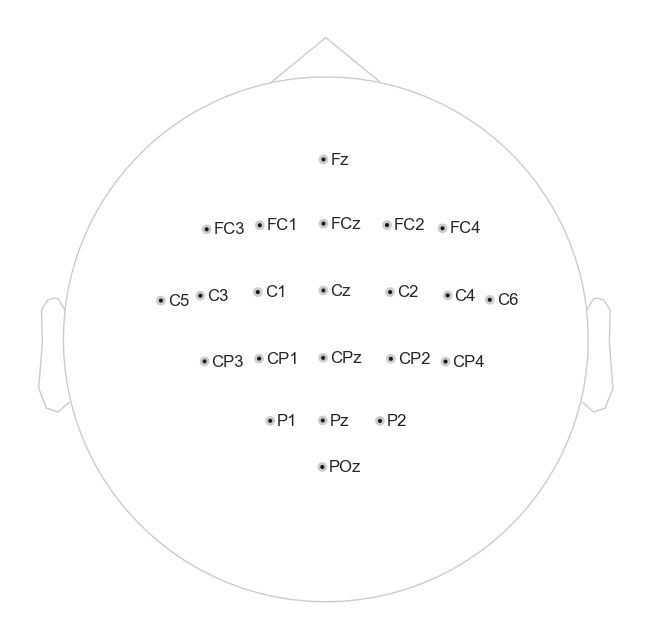

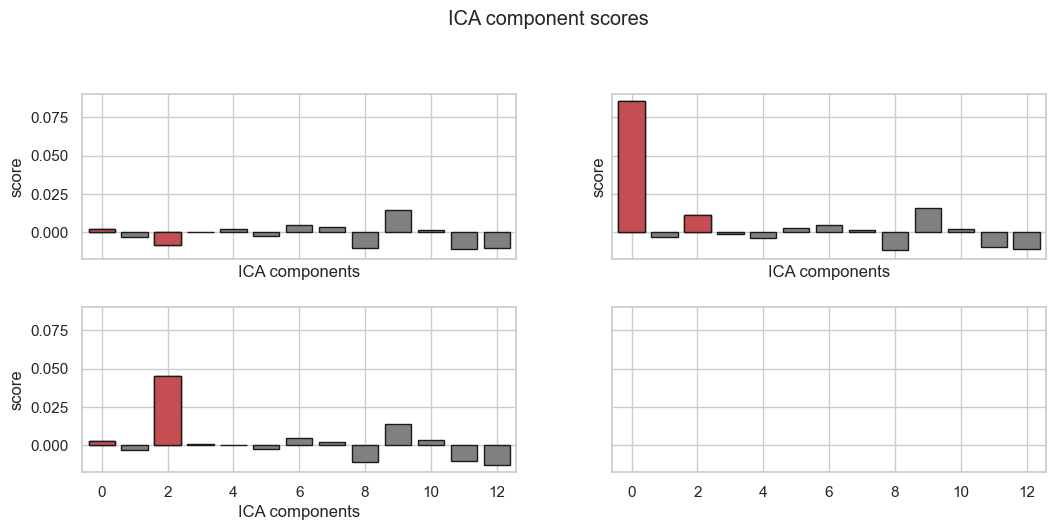

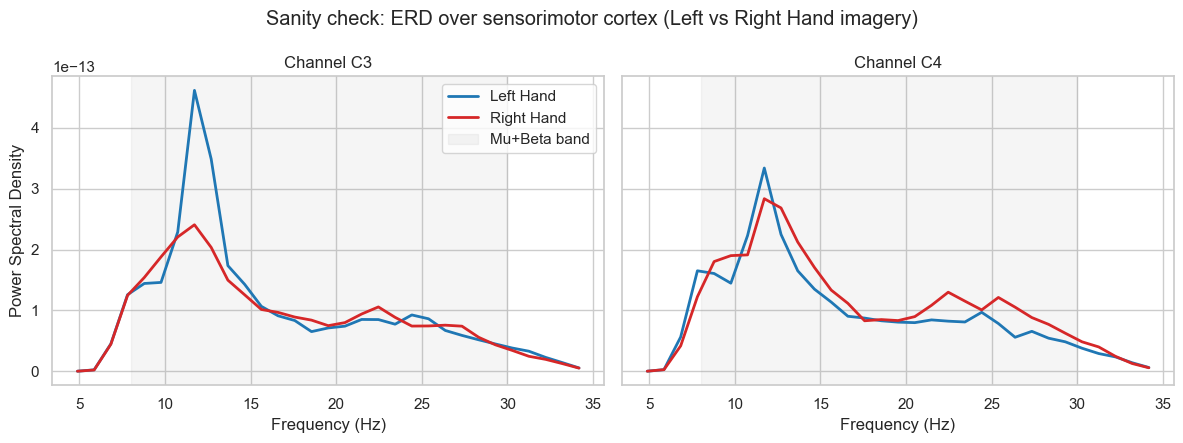

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
colors = {1: '#1f77b4', 2: '#d62728'}
labels_of_interest = {1: 'Left Hand', 2: 'Right Hand'}

for ax, ch in zip(axes, ['C3', 'C4']):
    for lab, color in colors.items():
        idx = np.where(labels == lab)[0]
        ep_data = data[idx, ch_names.index(ch), :]
        psd, freqs = mne.time_frequency.psd_array_welch(
            ep_data, sfreq=sfreq, fmin=4, fmax=35, n_fft=256, verbose=False)
        ax.plot(freqs, psd.mean(axis=0), label=labels_of_interest[lab], color=color, lw=2)
    ax.set_title(f'Channel {ch}')
    ax.set_xlabel('Frequency (Hz)')
    ax.axvspan(8, 30, color='grey', alpha=0.08, label='Mu+Beta band' if ch == 'C3' else None)
axes[0].set_ylabel('Power Spectral Density')
axes[0].legend()
plt.suptitle('Sanity check: ERD over sensorimotor cortex (Left vs Right Hand imagery)')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/erd_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Feature Extraction via Wavelet Packet Decomposition (WPD)

Unlike the standard Discrete Wavelet Transform (DWT) which only splits low frequencies, WPD recursively decomposes both low- and high-frequency branches. This yields a balanced, fine-grained **filter bank** that we use for two purposes:

1. **Statistical Features:** Extracting Energy, Variance, and Shannon Entropy directly from the coefficients to capture power distribution across sub-bands.
2. **Reconstruction:** Zeroing out all leaf nodes except one and applying the inverse transform. This isolates specific frequency bands of the multi-channel signal, which we then pass to CSP (Stage 3).

### 2.1 Decomposition Depth & Sub-band Selection

We use the **`db4`** (Daubechies-4) wavelet—a standard choice for EEG due to its balance of smoothness and compact support—with a **4-level decomposition**. This splits our 0-125 Hz Nyquist range into 16 equal sub-bands (approx. 7.8 Hz each).

Since Stage 1 already band-passes the signal to 8-30 Hz, we programmatically select only the leaf nodes that overlap with this range, rather than hardcoding specific node indices.


In [10]:
WAVELET = 'db4'
WPD_LEVEL = 4
FILTER_BAND = (8.0, 30.0)  # must match the Stage-1 bandpass filter

# Enumerate all leaf nodes at the chosen depth, in frequency order, and compute
# the frequency range each node covers.
_dummy = pywt.WaveletPacket(data=data[0, 0, :], wavelet=WAVELET, mode='symmetric',
                             maxlevel=WPD_LEVEL)
all_nodes = [node.path for node in _dummy.get_level(WPD_LEVEL, order='freq')]
band_width = (sfreq / 2) / len(all_nodes)

node_freq_table = []
relevant_nodes = []
for i, path in enumerate(all_nodes):
    lo, hi = i * band_width, (i + 1) * band_width
    overlaps = (hi > FILTER_BAND[0]) and (lo < FILTER_BAND[1])
    node_freq_table.append((path, lo, hi, overlaps))
    if overlaps:
        relevant_nodes.append(path)

freq_df = pd.DataFrame(node_freq_table, columns=['node', 'low_Hz', 'high_Hz', 'relevant'])
print(freq_df[freq_df['relevant']].to_string(index=False))
print(f"\nSelected {len(relevant_nodes)} relevant WPD sub-bands: {relevant_nodes}")

# Convenience lookup: node path -> (low_Hz, high_Hz), used later for plot labels
node_freq_range = {path: (lo, hi) for path, lo, hi, _ in node_freq_table}


node  low_Hz  high_Hz  relevant
aaad  7.8125  15.6250      True
aadd 15.6250  23.4375      True
aada 23.4375  31.2500      True

Selected 3 relevant WPD sub-bands: ['aaad', 'aadd', 'aada']


### 2.2 Statistical feature functions


In [11]:
def wpd_statistical_features(coeffs: np.ndarray) -> tuple:
    # Energy, variance, and Shannon entropy of a wavelet-coefficient array.
    energy = float(np.sum(coeffs ** 2))
    variance = float(np.var(coeffs))
    power = coeffs ** 2
    total_power = power.sum()
    if total_power > 0:
        p = power[power > 0] / total_power
        entropy = float(-np.sum(p * np.log(p)))
    else:
        entropy = 0.0
    return energy, variance, entropy


### 2.3 Extracting features for every epoch


In [12]:
n_epochs, n_channels, n_times = data.shape
n_stats = 3  # energy, variance, entropy

stat_features = np.zeros((n_epochs, n_channels, len(relevant_nodes), n_stats))
subband_signals = {node: np.zeros((n_epochs, n_channels, n_times)) for node in relevant_nodes}

for e in range(n_epochs):
    for c in range(n_channels):
        wp = pywt.WaveletPacket(data=data[e, c, :], wavelet=WAVELET,
                                 mode='symmetric', maxlevel=WPD_LEVEL)
        for ni, node_path in enumerate(relevant_nodes):
            coeffs = wp[node_path].data
            stat_features[e, c, ni, :] = wpd_statistical_features(coeffs)

            # Reconstruct only this sub-band: build an empty packet tree and
            # populate just the target leaf node, then inverse-transform.
            wp_rec = pywt.WaveletPacket(data=None, wavelet=WAVELET,
                                         mode='symmetric', maxlevel=WPD_LEVEL)
            wp_rec[node_path] = coeffs
            reconstructed = wp_rec.reconstruct(update=False)
            subband_signals[node_path][e, c, :] = reconstructed[:n_times]

print(f"Statistical feature tensor: {stat_features.shape} "
      f"(epochs, channels, sub-bands, stats)")
print(f"Reconstructed sub-band signals: { {k: v.shape for k, v in subband_signals.items()} }")


Statistical feature tensor: (288, 22, 3, 3) (epochs, channels, sub-bands, stats)
Reconstructed sub-band signals: {'aaad': (288, 22, 751), 'aadd': (288, 22, 751), 'aada': (288, 22, 751)}


## 3. Feature Extraction and Selection using Common Spatial Patterns (CSP)

WPD and CSP capture different aspects of the EEG signal:

- **WPD** extracts time-frequency information from each channel.
- **CSP** identifies spatial patterns that best separate the classes across channels.

Instead of choosing between them, we combine both methods. The WPD sub-bands act as a data-driven filter bank, and a separate CSP model is fitted to the reconstructed signal from each selected sub-band. This is similar to the Filter-Bank CSP (FBCSP) approach, but uses WPD-based sub-bands instead of manually selected band-pass filters.

For each trial, we concatenate:

- CSP log-variance features from all selected sub-bands.
- WPD statistical features (Energy, Variance, and Entropy) from the sensorimotor channels.

This hybrid representation allows CSP to capture discriminative spatial patterns while the WPD features preserve additional information about the distribution and concentration of energy within each sub-band.

### Avoiding Data Leakage

CSP filters are learned from labelled data, so they must be fitted only on the training set. The same rule applies to the feature scaler.

Therefore, we split the data before fitting any component and use the training set only to fit:

- The CSP filters for each sub-band.
- The feature scaler.

The validation and test sets are transformed using these already-fitted components.


In [13]:
idx_all = np.arange(n_epochs)

# 60% train / 20% validation / 20% test, stratified to keep classes balanced
idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all, labels, test_size=0.4, stratify=labels, random_state=RANDOM_STATE)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Train: {len(idx_train)} | Validation: {len(idx_val)} | Test: {len(idx_test)}")
print("Class balance (train):", np.bincount(y_train)[1:])
print("Class balance (val):  ", np.bincount(y_val)[1:])
print("Class balance (test): ", np.bincount(y_test)[1:])


Train: 172 | Validation: 58 | Test: 58
Class balance (train): [43 43 43 43]
Class balance (val):   [14 15 14 15]
Class balance (test):  [15 14 15 14]


### 3.1 Fitting CSP per WPD sub-band (Filter-Bank CSP)



In [14]:
N_CSP_COMPONENTS = 4
csp_models = {}
csp_feats = {'train': [], 'val': [], 'test': []}

for node in relevant_nodes:
    X_band = subband_signals[node]  # (n_epochs, n_channels, n_times)
    csp = CSP(n_components=N_CSP_COMPONENTS, reg='ledoit_wolf',
              log=True, norm_trace=False)
    csp.fit(X_band[idx_train], y_train)   # fit on TRAIN ONLY
    csp_models[node] = csp

    csp_feats['train'].append(csp.transform(X_band[idx_train]))
    csp_feats['val'].append(csp.transform(X_band[idx_val]))
    csp_feats['test'].append(csp.transform(X_band[idx_test]))

csp_train = np.concatenate(csp_feats['train'], axis=1)
csp_val = np.concatenate(csp_feats['val'], axis=1)
csp_test = np.concatenate(csp_feats['test'], axis=1)
print(f"CSP feature shapes -> train: {csp_train.shape}, val: {csp_val.shape}, test: {csp_test.shape}")


CSP feature shapes -> train: (172, 12), val: (58, 12), test: (58, 12)


### 3.2 Adding WPD statistical features from sensorimotor electrodes


In [15]:
ROI_CHANNELS = ['C3', 'C1', 'Cz', 'C2', 'C4']
roi_idx = [ch_names.index(ch) for ch in ROI_CHANNELS]

stat_roi = stat_features[:, roi_idx, :, :]            # (n_epochs, 5, 3, 3)
stat_roi_flat = stat_roi.reshape(n_epochs, -1)         # (n_epochs, 45)

stat_train = stat_roi_flat[idx_train]
stat_val = stat_roi_flat[idx_val]
stat_test = stat_roi_flat[idx_test]

# ---- Combine CSP + WPD statistical features into the final hybrid vector ----
X_train_raw = np.concatenate([csp_train, stat_train], axis=1)
X_val_raw = np.concatenate([csp_val, stat_val], axis=1)
X_test_raw = np.concatenate([csp_test, stat_test], axis=1)

scaler = StandardScaler().fit(X_train_raw)  # fit on TRAIN ONLY
X_train = scaler.transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

n_features = X_train.shape[1]
print(f"Final hybrid feature vector length: {n_features} "
      f"({N_CSP_COMPONENTS * len(relevant_nodes)} CSP + "
      f"{len(ROI_CHANNELS) * len(relevant_nodes) * n_stats} WPD-statistical)")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")


Final hybrid feature vector length: 57 (12 CSP + 45 WPD-statistical)
X_train: (172, 57), X_val: (58, 57), X_test: (58, 57)


### 3.3 Quick sanity baseline

Before building the MLP, it's good practice to check how much signal a simple
linear model can already extract from these hybrid features — this gives us a
baseline to beat, and a fast way to confirm the features are informative before
investing in a heavier model.

In [16]:
baseline_clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(baseline_clf, X_train, y_train, cv=cv)
print(f"Logistic Regression 5-fold CV accuracy (train set): "
      f"{cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

baseline_clf.fit(X_train, y_train)
baseline_test_acc = baseline_clf.score(X_test, y_test)
print(f"Logistic Regression held-out test accuracy: {baseline_test_acc:.3f}")
print("(Chance level for 4 balanced classes = 0.25)")


Logistic Regression 5-fold CV accuracy (train set): 0.739 +/- 0.039
Logistic Regression held-out test accuracy: 0.793
(Chance level for 4 balanced classes = 0.25)


## 4. Classification using a Multi-Layer Perceptron (PyTorch)



In [17]:
class MotorImageryMLP(nn.Module):
    def __init__(self, in_features: int, n_classes: int = 4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)  # raw logits; softmax is applied inside CrossEntropyLoss


### 4.1 Preparing tensors and data loaders

Labels are shifted from `{1,2,3,4}` to `{0,1,2,3}` as required by PyTorch's
`CrossEntropyLoss`.

In [18]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train - 1, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
y_val_t = torch.tensor(y_val - 1, dtype=torch.long).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test - 1, dtype=torch.long).to(DEVICE)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                           generator=torch.Generator().manual_seed(RANDOM_STATE))

model = MotorImageryMLP(in_features=n_features, n_classes=4).to(DEVICE)
print(model)


MotorImageryMLP(
  (net): Sequential(
    (0): Linear(in_features=57, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=4, bias=True)
  )
)


### 4.2 Training loop with early stopping

We train for up to 150 epochs, tracking train/validation loss and accuracy every
epoch, and keep the model weights from the epoch with the **lowest validation
loss** (early stopping with patience = 30 epochs).

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

N_EPOCHS = 150
PATIENCE = 30

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_state = None
patience_counter = 0

for epoch in range(N_EPOCHS):
    # ---- training ----
    model.train()
    running_loss, correct, seen = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        seen += xb.size(0)
    train_loss, train_acc = running_loss / seen, correct / seen

    # ---- validation ----
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
        val_acc = (val_logits.argmax(dim=1) == y_val_t).float().mean().item()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == N_EPOCHS - 1:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
              f"| val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} "
              f"(no val_loss improvement for {PATIENCE} epochs).")
        break

model.load_state_dict(best_state)
print(f"\nRestored best model weights (lowest validation loss = {best_val_loss:.4f}).")


Epoch   0 | train_loss=1.3213 train_acc=0.378 | val_loss=1.1631 val_acc=0.534
Epoch  10 | train_loss=0.6272 train_acc=0.762 | val_loss=0.5955 val_acc=0.828
Epoch  20 | train_loss=0.2810 train_acc=0.924 | val_loss=0.4370 val_acc=0.793
Epoch  30 | train_loss=0.2259 train_acc=0.942 | val_loss=0.4256 val_acc=0.776
Epoch  40 | train_loss=0.2099 train_acc=0.930 | val_loss=0.4136 val_acc=0.828
Epoch  50 | train_loss=0.2802 train_acc=0.890 | val_loss=0.4419 val_acc=0.793
Epoch  60 | train_loss=0.1640 train_acc=0.942 | val_loss=0.4994 val_acc=0.759

Early stopping triggered at epoch 65 (no val_loss improvement for 30 epochs).

Restored best model weights (lowest validation loss = 0.3876).


## 5. Evaluation and Visualization


In [20]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    y_pred = test_logits.argmax(dim=1).cpu().numpy()
y_true = y_test_t.cpu().numpy()

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=range(4))
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro')

print(f"Overall Test Accuracy: {acc:.3f}\n")

metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support,
})
metrics_df.loc['Macro Avg'] = ['Macro Avg', macro_p, macro_r, macro_f1, support.sum()]
display(metrics_df.round(3))

print("\nFull scikit-learn classification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Overall Test Accuracy: 0.759



,Class,Precision,Recall,F1-Score,Support
0,Left Hand,1.000,0.667,0.800,15
1,Right Hand,0.722,0.929,0.812,14
2,Feet,0.632,0.800,0.706,15
3,Tongue,0.818,0.643,0.720,14
Macro Avg,Macro Avg,0.793,0.760,0.760,58



Full scikit-learn classification report:

              precision    recall  f1-score   support

   Left Hand       1.00      0.67      0.80        15
  Right Hand       0.72      0.93      0.81        14
        Feet       0.63      0.80      0.71        15
      Tongue       0.82      0.64      0.72        14

    accuracy                           0.76        58
   macro avg       0.79      0.76      0.76        58
weighted avg       0.79      0.76      0.76        58



### 5.2 Confusion matrix

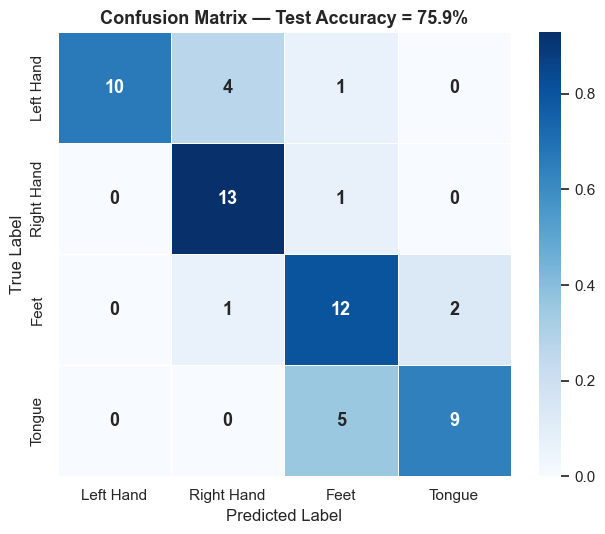

In [21]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', cbar=True,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — Test Accuracy = {acc:.1%}', fontsize=13, weight='bold')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Training curves

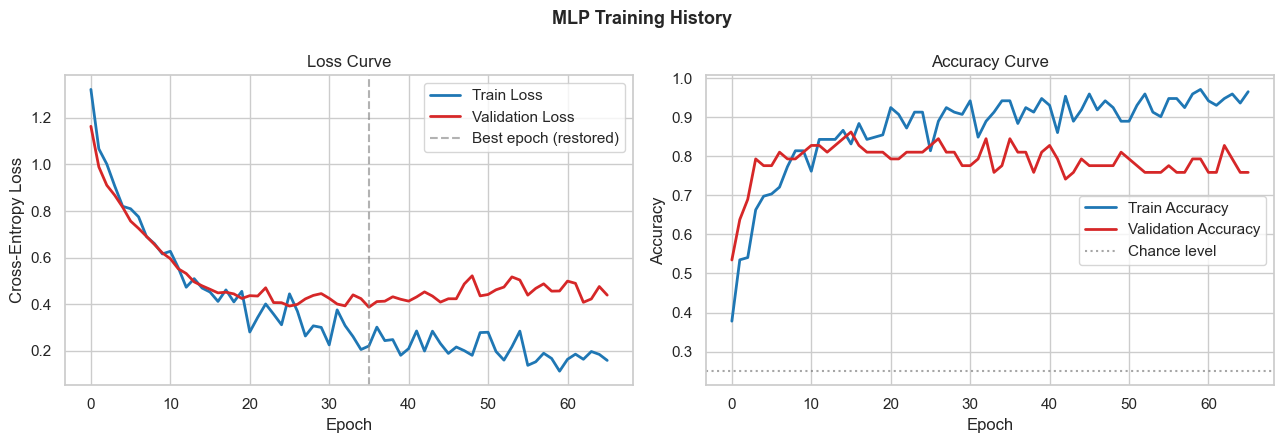

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
axes[0].plot(history['val_loss'], label='Validation Loss', color='#d62728', lw=2)
axes[0].axvline(len(history['train_loss']) - PATIENCE - 1, color='grey', ls='--',
                 alpha=0.6, label='Best epoch (restored)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Accuracy', color='#1f77b4', lw=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', color='#d62728', lw=2)
axes[1].axhline(0.25, color='grey', ls=':', alpha=0.7, label='Chance level')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].legend()

plt.suptitle('MLP Training History', fontsize=13, weight='bold')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 CSP Spatial Patterns (Topographic Maps)

CSP patterns show how each spatial component projects back onto the scalp and
indicate which regions contribute most to classification in a given sub-band.

For each WPD sub-band, we plot the top four CSP components. We expect the
strongest patterns to appear around the central sensorimotor electrodes, which
is consistent with motor-imagery-related activity.


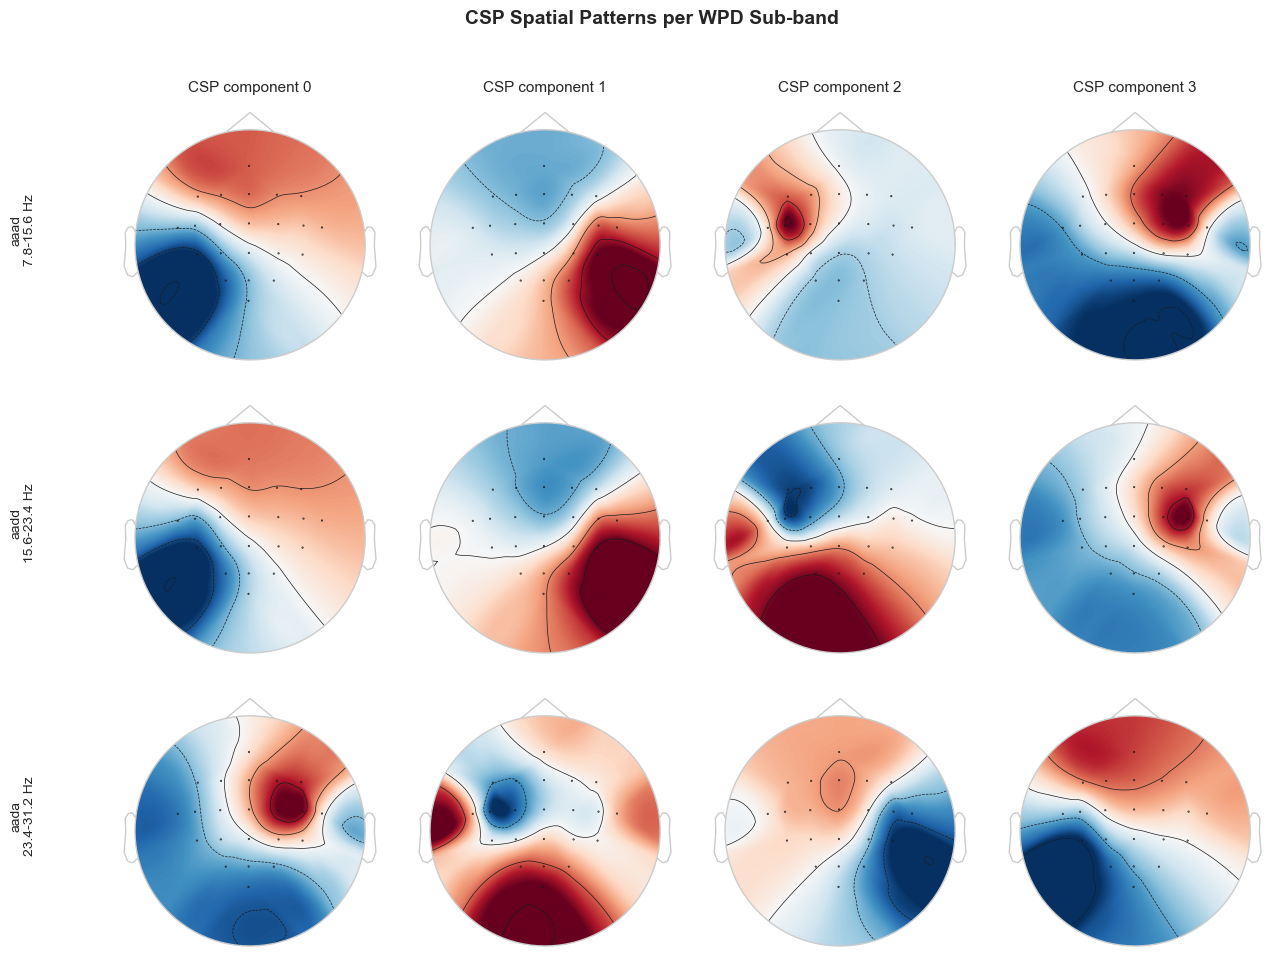

In [23]:
fig, axes = plt.subplots(len(relevant_nodes), N_CSP_COMPONENTS,
                          figsize=(3.2 * N_CSP_COMPONENTS, 3.2 * len(relevant_nodes)))

for row, node in enumerate(relevant_nodes):
    csp = csp_models[node]
    lo, hi = node_freq_range[node]
    for col in range(N_CSP_COMPONENTS):
        ax = axes[row, col]
        pattern = csp.patterns_[col]
        mne.viz.plot_topomap(pattern, epochs_mi.info, axes=ax, show=False,
                              cmap='RdBu_r', sensors=True, contours=4)
        if row == 0:
            ax.set_title(f'CSP component {col}', fontsize=11)
        if col == 0:
            ax.text(-0.32, 0.5, f'{node}\n{lo:.1f}-{hi:.1f} Hz', fontsize=10,
                    rotation=90, va='center', ha='center', transform=ax.transAxes)

plt.suptitle('CSP Spatial Patterns per WPD Sub-band', fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/csp_topomaps.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 WPD Energy Features Across Classes

We visualize the WPD energy feature, averaged across the sensorimotor ROI
channels, for each motor-imagery class and sub-band.

Differences between the class distributions indicate that the WPD energy
features contain useful discriminative information and help explain the
classifier's performance.


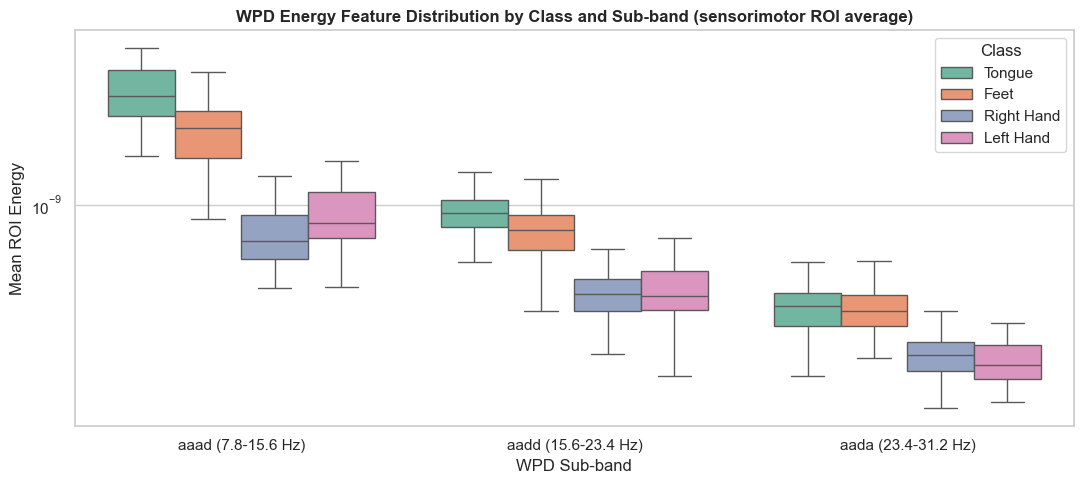

In [24]:
energy_idx = 0  

energy_only = stat_features[:, :, :, energy_idx]      # (n_epochs, n_channels, n_subbands)
roi_energy = energy_only[:, roi_idx, :].mean(axis=1)  # (n_epochs, n_subbands)

column_labels = [f'{n} ({node_freq_range[n][0]:.1f}-{node_freq_range[n][1]:.1f} Hz)'
                  for n in relevant_nodes]
plot_df = pd.DataFrame(roi_energy, columns=column_labels)
plot_df['Class'] = [class_names[l - 1] for l in labels]
plot_df_melted = plot_df.melt(id_vars='Class', var_name='WPD Sub-band', value_name='Mean ROI Energy')

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=plot_df_melted, x='WPD Sub-band', y='Mean ROI Energy', hue='Class',
            palette='Set2', ax=ax, showfliers=False)
ax.set_yscale('log')
ax.set_title('WPD Energy Feature Distribution by Class and Sub-band '
             '(sensorimotor ROI average)', fontsize=12, weight='bold')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/wpd_energy_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Cross-Subject Generalization: Testing on All Nine Subjects

The MLP above was trained (and validated/tested) using **only Subject 1** data. A central question in BCI research is how well a subject-specific model transfers to *unseen* subjects, since EEG signals vary substantially between individuals.

Below we run the fully-fitted pipeline &mdash; the same WPD sub-bands, the same **already-fitted** CSP filters, the same **already-fitted** feature scaler, and the same **already-trained** MLP (all fitted/trained on Subject 1 only, never refit here) &mdash; in test/inference mode on Subjects 1 through 9:

* **Subject 1:** we reuse the original held-out test split from Section 3 (`X_test_t` / `y_test_t`), since the rest of that recording was already used for training/validation.
* **Subjects 2-9:** the entire recording is unseen by the model, so every trial from each subject serves as a test trial.

Raw recordings are expected at `data/raw/A0<N>T.gdf`.

In [25]:
import os
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from IPython.display import display

DATA_DIR = 'data/raw'
SUBJECT_IDS = [f'A0{i}T' for i in range(1, 10)]  # A01T ... A09T

TARGET_EVENT_ID = {'769': 1, '770': 2, '771': 3, '772': 4} 

def preprocess_subject(gdf_path):
    """Reproduces Section 1 (preprocessing) for one subject's raw recording."""
    raw_s = mne.io.read_raw_gdf(gdf_path, preload=True)
    raw_s.rename_channels(channel_mapping)
    raw_s.set_channel_types({'EOG-left': 'eog', 'EOG-central': 'eog', 'EOG-right': 'eog'})
    raw_s.set_montage(montage, on_missing='ignore')

    raw_s.set_eeg_reference('average', projection=False, ch_type='eeg')
    raw_for_ica_s = raw_s.copy().filter(l_freq=1.0, h_freq=40.0, picks='eeg')
    
    ica_s = mne.preprocessing.ICA(n_components=0.99, method='fastica',
                                   random_state=RANDOM_STATE, max_iter='auto')
    ica_s.fit(raw_for_ica_s, picks='eeg')
    eog_idx_s, _ = ica_s.find_bads_eog(
        raw_for_ica_s, ch_name=['EOG-left', 'EOG-central', 'EOG-right'], threshold=2.5)
    ica_s.exclude = eog_idx_s
    ica_s.apply(raw_s)

    raw_s.filter(l_freq=8.0, h_freq=30.0, picks='eeg', method='fir',
                 fir_design='firwin', phase='zero')

    events_s, _ = mne.events_from_annotations(raw_s, event_id=TARGET_EVENT_ID)
    
    epochs_s = mne.Epochs(raw_s, events=events_s, event_id=TARGET_EVENT_ID,
                           tmin=-0.5, tmax=4.0, baseline=(-0.5, 0.0),
                           picks='eeg', preload=True)
                           
    labels_s = epochs_s.events[:, 2] 
    
    epochs_mi_s = epochs_s.copy().crop(tmin=0.5, tmax=3.5)
    return epochs_mi_s.get_data(), labels_s, epochs_mi_s.ch_names



def extract_hybrid_features(data_s, ch_names_s):
    n_ep, n_ch, n_t = data_s.shape
    roi_idx_s = [ch_names_s.index(ch) for ch in ROI_CHANNELS]

    stat_feats_s = np.zeros((n_ep, n_ch, len(relevant_nodes), n_stats))
    subband_s = {node: np.zeros((n_ep, n_ch, n_t)) for node in relevant_nodes}

    for e in range(n_ep):
        for c in range(n_ch):
            wp = pywt.WaveletPacket(data=data_s[e, c, :], wavelet=WAVELET,
                                     mode='symmetric', maxlevel=WPD_LEVEL)
            for ni, node_path in enumerate(relevant_nodes):
                coeffs = wp[node_path].data
                stat_feats_s[e, c, ni, :] = wpd_statistical_features(coeffs)
                wp_rec = pywt.WaveletPacket(data=None, wavelet=WAVELET,
                                             mode='symmetric', maxlevel=WPD_LEVEL)
                wp_rec[node_path] = coeffs
                subband_s[node_path][e, c, :] = wp_rec.reconstruct(update=False)[:n_t]

    csp_feat_s = np.concatenate(
        [csp_models[node].transform(subband_s[node]) for node in relevant_nodes], axis=1)
    stat_roi_s = stat_feats_s[:, roi_idx_s, :, :].reshape(n_ep, -1)
    X_raw_s = np.concatenate([csp_feat_s, stat_roi_s], axis=1)
    return scaler.transform(X_raw_s)


@torch.no_grad()
def run_test_mode(X, labels_1idx):
    """Runs the already-trained model in eval/inference mode."""
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    preds = model(X_t).argmax(dim=1).cpu().numpy()
    
    return preds, labels_1idx - 1  


cross_subject_results = {
    'A01T': {'y_true': y_true, 'y_pred': y_pred} 
}

for sid in SUBJECT_IDS[1:]:
    gdf_path = os.path.join(DATA_DIR, f'{sid}.gdf')
    if not os.path.exists(gdf_path):
        print(f"[skipping {sid}] file not found: {gdf_path}")
        continue
    print(f"Processing {sid} ...")
    data_s, labels_s, ch_names_s = preprocess_subject(gdf_path)
    X_s = extract_hybrid_features(data_s, ch_names_s)
    preds_s, y_true_s = run_test_mode(X_s, labels_s)
    cross_subject_results[sid] = {'y_true': y_true_s, 'y_pred': preds_s}

summary_rows = []
for sid, res in cross_subject_results.items():
    acc_s = accuracy_score(res['y_true'], res['y_pred'])
    _, _, f1_s, _ = precision_recall_fscore_support(
        res['y_true'], res['y_pred'], average='macro', zero_division=0)
    summary_rows.append({'Subject': sid, 'N Trials': len(res['y_true']),
                          'Accuracy': acc_s, 'Macro F1': f1_s})

cross_subject_df = pd.DataFrame(summary_rows)
held_out_mask = cross_subject_df['Subject'] != 'A01T'

print("\nPer-subject test performance (model trained on Subject 1 only):\n")
display(cross_subject_df.round(3))
print(f"\nSubject 1 (trained on) test accuracy: "
      f"{cross_subject_df.loc[~held_out_mask, 'Accuracy'].iloc[0]:.3f}")
print(f"Mean accuracy on unseen subjects (2-9): "
      f"{cross_subject_df.loc[held_out_mask, 'Accuracy'].mean():.3f} "
      f"+/- {cross_subject_df.loc[held_out_mask, 'Accuracy'].std():.3f}")


Processing A02T ...
Processing A03T ...
Processing A04T ...
Processing A05T ...
Processing A06T ...
Processing A07T ...
Processing A08T ...
Processing A09T ...

Per-subject test performance (model trained on Subject 1 only):



,Subject,N Trials,Accuracy,Macro F1
0,A01T,58,0.759,0.760
1,A02T,288,0.316,0.254
2,A03T,288,0.431,0.310
3,A04T,288,0.326,0.296
4,A05T,288,0.274,0.174
5,A06T,288,0.253,0.113
6,A07T,288,0.424,0.372
7,A08T,288,0.257,0.115
8,A09T,288,0.253,0.108



Subject 1 (trained on) test accuracy: 0.759
Mean accuracy on unseen subjects (2-9): 0.317 +/- 0.074


### 6.2 Visualizing cross-subject generalization

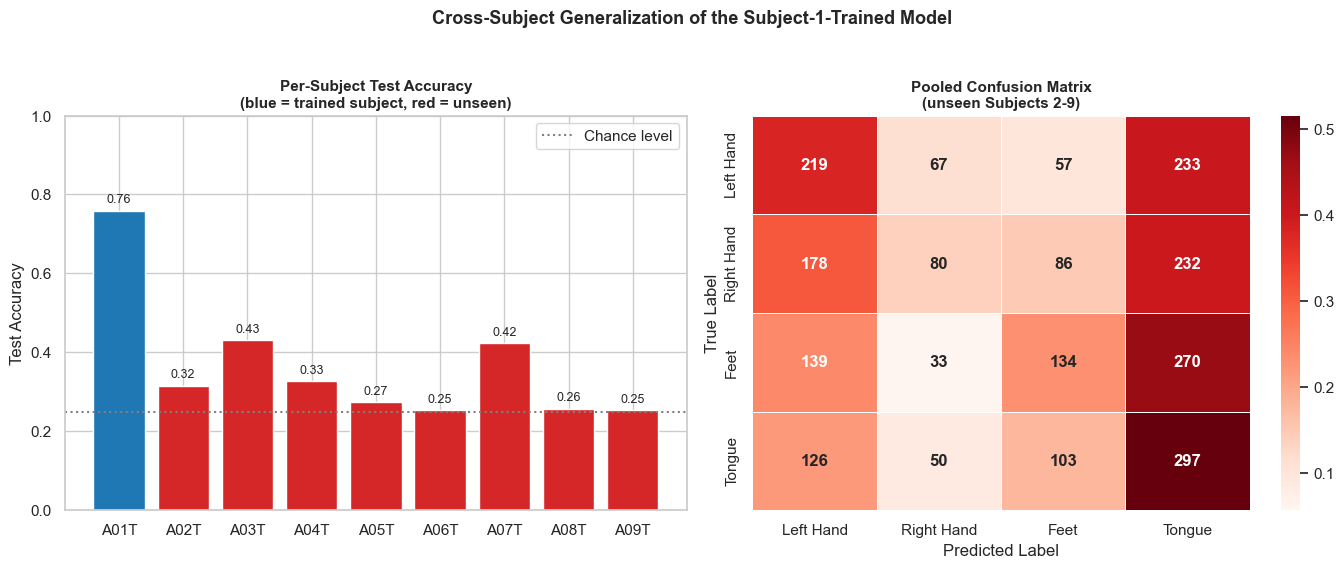

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ---- Left panel: per-subject accuracy bar chart ----
bar_colors = ['#1f77b4' if not m else '#d62728' for m in held_out_mask]
axes[0].bar(cross_subject_df['Subject'], cross_subject_df['Accuracy'], color=bar_colors)
axes[0].axhline(0.25, color='grey', ls=':', lw=1.5, label='Chance level')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Per-Subject Test Accuracy\n(blue = trained subject, red = unseen)',
                   fontsize=11, weight='bold')
axes[0].legend()
for i, v in enumerate(cross_subject_df['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

# ---- Right panel: pooled confusion matrix across unseen subjects ----
y_true_pooled = np.concatenate([cross_subject_results[s]['y_true']
                                 for s in cross_subject_df.loc[held_out_mask, 'Subject']])
y_pred_pooled = np.concatenate([cross_subject_results[s]['y_pred']
                                 for s in cross_subject_df.loc[held_out_mask, 'Subject']])
cm_pooled = confusion_matrix(y_true_pooled, y_pred_pooled, labels=range(4))
cm_pooled_norm = cm_pooled.astype(float) / cm_pooled.sum(axis=1, keepdims=True)

sns.heatmap(cm_pooled_norm, annot=cm_pooled, fmt='d', cmap='Reds', cbar=True,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='white', ax=axes[1],
            annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Pooled Confusion Matrix\n(unseen Subjects 2-9)', fontsize=11, weight='bold')

plt.suptitle('Cross-Subject Generalization of the Subject-1-Trained Model',
             fontsize=13, weight='bold', y=1.03)
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/cross_subject_generalization.png', dpi=150, bbox_inches='tight')
plt.show()


OVERALL CROSS-SUBJECT SUMMARY
Mean accuracy across ALL 9 subjects     : 0.366 +/- 0.163
Trained subject (A01T) accuracy         : 0.759
Mean accuracy on UNSEEN subjects (2-9)  : 0.317 +/- 0.074
Mean macro-F1 on UNSEEN subjects (2-9)  : 0.218
Generalization gap (trained - unseen)   : 0.442
Chance level (4 balanced classes)       : 0.250


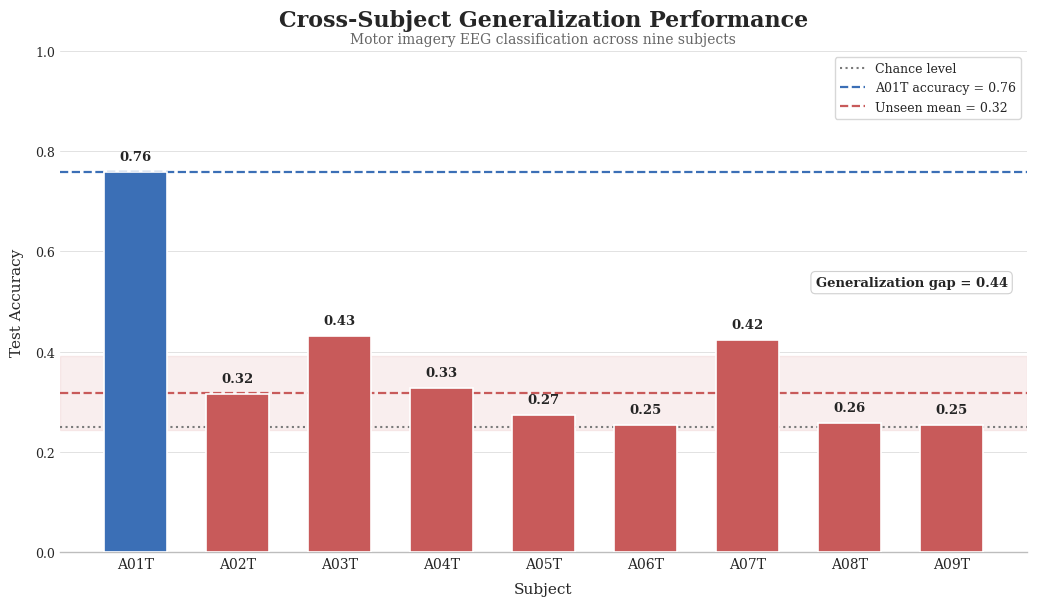

In [ ]:
# ============================================================
# 6.3 Overall summary: average performance and generalization gap
#     across all nine subjects, condensed into a single chart.
# ============================================================

overall_mean_acc_all = cross_subject_df['Accuracy'].mean()
overall_std_acc_all = cross_subject_df['Accuracy'].std()

unseen_acc = cross_subject_df.loc[held_out_mask, 'Accuracy']
unseen_f1 = cross_subject_df.loc[held_out_mask, 'Macro F1']
trained_acc = cross_subject_df.loc[~held_out_mask, 'Accuracy'].iloc[0]

mean_unseen_acc = unseen_acc.mean()
std_unseen_acc = unseen_acc.std()
mean_unseen_f1 = unseen_f1.mean()
generalization_gap = trained_acc - mean_unseen_acc

print("=" * 60)
print("OVERALL CROSS-SUBJECT SUMMARY")
print("=" * 60)
print(f"Mean accuracy across ALL 9 subjects     : {overall_mean_acc_all:.3f} +/- {overall_std_acc_all:.3f}")
print(f"Trained subject (A01T) accuracy         : {trained_acc:.3f}")
print(f"Mean accuracy on UNSEEN subjects (2-9)  : {mean_unseen_acc:.3f} +/- {std_unseen_acc:.3f}")
print(f"Mean macro-F1 on UNSEEN subjects (2-9)  : {mean_unseen_f1:.3f}")
print(f"Generalization gap (trained - unseen)   : {generalization_gap:.3f}")
print(f"Chance level (4 balanced classes)       : 0.250")
print("=" * 60)

# ---- Publication-style overall chart ----
fig, ax = plt.subplots(figsize=(10.5, 6.2))

subjects = cross_subject_df['Subject']
accuracies = cross_subject_df['Accuracy']

trained_color = '#3B6FB6'
unseen_color = '#C85A5A'
chance_color = '#7A7A7A'
text_color = '#252525'

bar_colors = [
    trained_color if not m else unseen_color
    for m in held_out_mask
]

bars = ax.bar(
    subjects,
    accuracies,
    width=0.62,
    color=bar_colors,
    edgecolor='white',
    linewidth=1.2,
    zorder=3
)

# Unseen-subject variability
ax.axhspan(
    mean_unseen_acc - std_unseen_acc,
    mean_unseen_acc + std_unseen_acc,
    color=unseen_color,
    alpha=0.10,
    zorder=1
)

# Reference lines
ax.axhline(
    0.25,
    color=chance_color,
    linestyle=':',
    linewidth=1.5,
    label='Chance level',
    zorder=2
)

ax.axhline(
    trained_acc,
    color=trained_color,
    linestyle='--',
    linewidth=1.6,
    label=f'A01T accuracy = {trained_acc:.2f}',
    zorder=2
)

ax.axhline(
    mean_unseen_acc,
    color=unseen_color,
    linestyle='--',
    linewidth=1.6,
    label=f'Unseen mean = {mean_unseen_acc:.2f}',
    zorder=2
)

# Accuracy labels
for bar, value in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.018,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontsize=9.5,
        fontweight='bold',
        color=text_color
    )

# Generalization gap annotation
ax.annotate(
    f'Generalization gap = {generalization_gap:.2f}',
    xy=(0.98, mean_unseen_acc + generalization_gap / 2),
    xycoords=('axes fraction', 'data'),
    ha='right',
    va='center',
    fontsize=9.5,
    fontweight='bold',
    color=text_color,
    bbox=dict(
        boxstyle='round,pad=0.35',
        facecolor='white',
        edgecolor='#D0D0D0',
        linewidth=0.8
    )
)

# Titles
ax.set_title(
    'Cross-Subject Generalization Performance',
    fontsize=16,
    fontweight='bold',
    pad=18
)

ax.text(
    0.5,
    1.01,
    'Motor imagery EEG classification across nine subjects',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=10,
    color='#666666'
)

ax.set_xlabel(
    'Subject',
    fontsize=11,
    labelpad=8
)

ax.set_ylabel(
    'Test Accuracy',
    fontsize=11,
    labelpad=8
)

# Axis limits
ax.set_ylim(0, 1.0)

# Grid
ax.grid(
    axis='y',
    linestyle='-',
    linewidth=0.7,
    color='#E2E2E2',
    zorder=0
)

ax.grid(
    axis='x',
    visible=False
)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#BDBDBD')

# Tick styling
ax.tick_params(
    axis='x',
    length=0,
    labelsize=10
)

ax.tick_params(
    axis='y',
    length=0,
    labelsize=9
)

# Legend
ax.legend(
    loc='upper right',
    fontsize=9,
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    edgecolor='#D5D5D5'
)

plt.tight_layout()

fig.savefig(
    f'{FIGURES_DIR}/overall_generalization_summary.png',
    dpi=400,
    bbox_inches='tight',
    facecolor='white'
)


plt.show()